In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

In [24]:
data_dir = Path("../Results/Output Data")
table_dir = Path("../Results/Table")
figure_dir = Path("../Results/Figures")
timezone = "Europe/Berlin"
strategies = ["UNHEDGED", "COARSE_CAL", "GRANULAR"]
strategy_names = {"UNHEDGED": "Unhedged", "COARSE_CAL": "Annual", "GRANULAR": "Granular"}
strategy_colors = {"UNHEDGED": "gray", "COARSE_CAL": "royalblue", "GRANULAR": "salmon"}
futures_columns = dict(zip(strategies, ["futures_cost_unhedged_eur", "futures_cost_coarse_eur", "futures_cost_granular_eur"]))
residual_cost_columns = dict(zip(strategies, ["residual_da_cost_unhedged_eur", "residual_da_cost_coarse_cal_eur", "residual_da_cost_granular_eur"]))
residual_columns = dict(zip(strategies, ["residual_unhedged_mwh", "residual_coarse_cal_mwh", "residual_granular_mwh"]))
plot_start = pd.Timestamp("2024-12-10", tz=timezone)
episode_start = pd.Timestamp("2024-12-11", tz=timezone)
episode_end = pd.Timestamp("2024-12-13", tz=timezone)
plot_end = pd.Timestamp("2024-12-14", tz=timezone)
for folder in [data_dir, table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11})

In [25]:
costs = pd.read_csv(data_dir / "03_cost_timeseries.csv")
stage5 = pd.read_csv(table_dir / "03_stage5_imbalance_summary.csv").set_index("Strategy")
costs["timestamp_utc"] = pd.to_datetime(costs["timestamp_utc"], utc=True)
costs["timestamp_local"] = costs["timestamp_utc"].dt.tz_convert(timezone)
expected_time = pd.date_range("2024-01-01", "2025-01-01", freq="15min", inclusive="left", tz=timezone).tz_convert("UTC")
assert pd.DatetimeIndex(costs["timestamp_utc"]).equals(expected_time), "The complete ordered 2024 quarter-hour grid is required."
assert costs.select_dtypes(include="number").notna().all().all(), "Missing cost inputs."
assert costs["total_actual_mwh"].gt(0).all(), "Actual interval load must be positive."
for strategy in strategies:
    costs[f"total_cost_{strategy.lower()}_eur"] = costs[futures_columns[strategy]] + costs[residual_cost_columns[strategy]] + costs["imbalance_settlement_eur"]
cost_columns = {strategy: f"total_cost_{strategy.lower()}_eur" for strategy in strategies}
display(costs[["timestamp_local", "forecast_mwh", "total_actual_mwh", *cost_columns.values()]].head())

,timestamp_local,forecast_mwh,total_actual_mwh,total_cost_unhedged_eur,total_cost_coarse_cal_eur,total_cost_granular_eur
0,2024-01-01 00:00:00+01:00,1.077136,1.093791,1.359335,86.080553,96.205260
1,2024-01-01 00:15:00+01:00,1.003301,1.018309,1.278897,86.000115,96.124822
2,2024-01-01 00:30:00+01:00,0.933171,0.947307,1.268985,85.990203,96.114910
3,2024-01-01 00:45:00+01:00,0.865711,0.880752,1.216920,85.938138,96.062845
4,2024-01-01 01:00:00+01:00,0.800915,0.813385,0.994791,85.814829,95.954198


In [26]:
sum_columns = ["forecast_mwh", "total_actual_mwh", *cost_columns.values()]
daily = costs.groupby(costs["timestamp_local"].dt.strftime("%Y-%m-%d"))[sum_columns].sum().rename_axis("date")
monthly = costs.groupby(costs["timestamp_local"].dt.strftime("%Y-%m"))[sum_columns].sum().rename_axis("month")
for strategy in strategies:
    daily[f"price_{strategy.lower()}_eur_mwh"] = daily[cost_columns[strategy]] / daily["total_actual_mwh"]
    monthly[f"price_{strategy.lower()}_eur_mwh"] = monthly[cost_columns[strategy]] / monthly["total_actual_mwh"]
daily.to_csv(data_dir / "04_daily_procurement.csv")
monthly.to_csv(data_dir / "04_monthly_procurement.csv")
display(monthly.round(2))

,forecast_mwh,total_actual_mwh,total_cost_unhedged_eur,total_cost_coarse_cal_eur,total_cost_granular_eur,price_unhedged_eur_mwh,price_coarse_cal_eur_mwh,price_granular_eur_mwh
month,,,,,,,,
2024-01,4266.45,4283.25,348628.09,349149.13,343131.58,81.39,81.51,80.11
2024-02,3898.35,3933.60,255218.53,310906.77,250244.69,64.88,79.04,63.62
2024-03,3930.24,3967.70,264264.17,311210.29,259318.73,66.60,78.44,65.36
2024-04,3548.44,3556.85,225102.74,282011.02,235291.68,63.29,79.29,66.15
2024-05,3367.84,3325.24,220875.70,267863.60,220443.09,66.42,80.55,66.29
2024-06,3073.39,3108.64,231564.21,251713.66,209224.80,74.49,80.97,67.30
2024-07,3081.67,3088.11,206705.02,252426.74,231250.19,66.94,81.74,74.88
2024-08,3143.99,3103.69,248033.20,240246.13,226404.25,79.92,77.41,72.95
2024-09,3199.17,3230.86,254950.90,253594.09,239856.85,78.91,78.49,74.24


In [27]:
annual_rows = []
actual_mwh = costs["total_actual_mwh"].sum()
unhedged_cost = costs[cost_columns["UNHEDGED"]].sum()
for strategy in strategies:
    final_cost = costs[cost_columns[strategy]].sum()
    monthly_price = monthly[f"price_{strategy.lower()}_eur_mwh"]
    residual = costs[residual_columns[strategy]]
    annual_rows.append({"Strategy": strategy, "Final Cost EUR": final_cost, "Average Procurement Price EUR/MWh": final_cost / actual_mwh, "Saving vs UNHEDGED EUR": unhedged_cost - final_cost, "Monthly Price Std EUR/MWh": monthly_price.std(ddof=1), "Monthly Price Range EUR/MWh": monthly_price.max() - monthly_price.min(), "Absolute Residual DA MWh": residual.abs().sum(), "Residual RMSE MWh": np.sqrt(np.mean(residual ** 2)), "Imbalance Settlement EUR": costs["imbalance_settlement_eur"].sum(), "Imbalance Premium EUR": costs["imbalance_premium_eur"].sum()})
annual_cost_risk = pd.DataFrame(annual_rows).set_index("Strategy")
annual_cost_risk.to_csv(table_dir / "04_annual_cost_risk.csv")
annual_table = annual_cost_risk.T.copy()
annual_table.index = ["Annual cost (EUR)", "Average price (EUR/MWh)", "Saving vs unhedged (EUR)", "Monthly price std. (EUR/MWh)", "Monthly price range (EUR/MWh)", "Absolute DA residual (MWh)", "Residual RMSE (MWh/15 min)", "Imbalance settlement (EUR)", "Imbalance premium (EUR)"]
annual_table = annual_table.astype(object)
for i in range(len(annual_table)):
    annual_table.iloc[i] = [f"{value:,.2f}" if i in [1, 3, 4, 6] else f"{value:,.0f}" for value in annual_table.iloc[i]]
annual_table = annual_table.rename(columns=strategy_names).rename_axis(index=None, columns=None)
(table_dir / "04_annual_cost_risk.tex").write_text(r"{\small" + "\n" + annual_table.to_latex(escape=True, column_format="lrrr") + "}\n", encoding="utf-8")
display(annual_table)

,Unhedged,Annual,Granular
Annual cost (EUR),"3,537,208","3,481,470","3,482,011"
Average price (EUR/MWh),82.00,80.71,80.72
Saving vs unhedged (EUR),0,"55,737","55,197"
Monthly price std. (EUR/MWh),20.15,2.43,18.56
Monthly price range (EUR/MWh),58.43,9.08,47.08
Absolute DA residual (MWh),"43,000","12,760","11,985"
Residual RMSE (MWh/15 min),1.32,0.44,0.42
Imbalance settlement (EUR),"30,504","30,504","30,504"
Imbalance premium (EUR),"13,589","13,589","13,589"


In [28]:
# Empirical upper-tail daily prices; quantiles use linear interpolation and ties are included.
tail_rows = []
for strategy in strategies:
    price = daily[f"price_{strategy.lower()}_eur_mwh"]
    var95, var99 = price.quantile([0.95, 0.99], interpolation="linear")
    tail95, tail99 = price[price >= var95], price[price >= var99]
    tail_rows.append({"Strategy": strategy, "Mean Daily Price EUR/MWh": price.mean(), "VaR95 EUR/MWh": var95, "ES95 EUR/MWh": tail95.mean(), "ES99 EUR/MWh": tail99.mean(), "Days": len(price), "Tail Days 95": len(tail95), "Tail Days 99": len(tail99)})
daily_price_tail = pd.DataFrame(tail_rows).set_index("Strategy")
daily_price_tail.to_csv(table_dir / "04_daily_price_tail.csv")
display(daily_price_tail.round(2))

,Mean Daily Price EUR/MWh,VaR95 EUR/MWh,ES95 EUR/MWh,ES99 EUR/MWh,Days,Tail Days 95,Tail Days 99
Strategy,,,,,,,
UNHEDGED,81.12,130.17,192.12,315.64,366,19,4
COARSE_CAL,80.60,90.50,100.53,129.04,366,19,4
GRANULAR,80.11,116.17,122.72,137.47,366,19,4


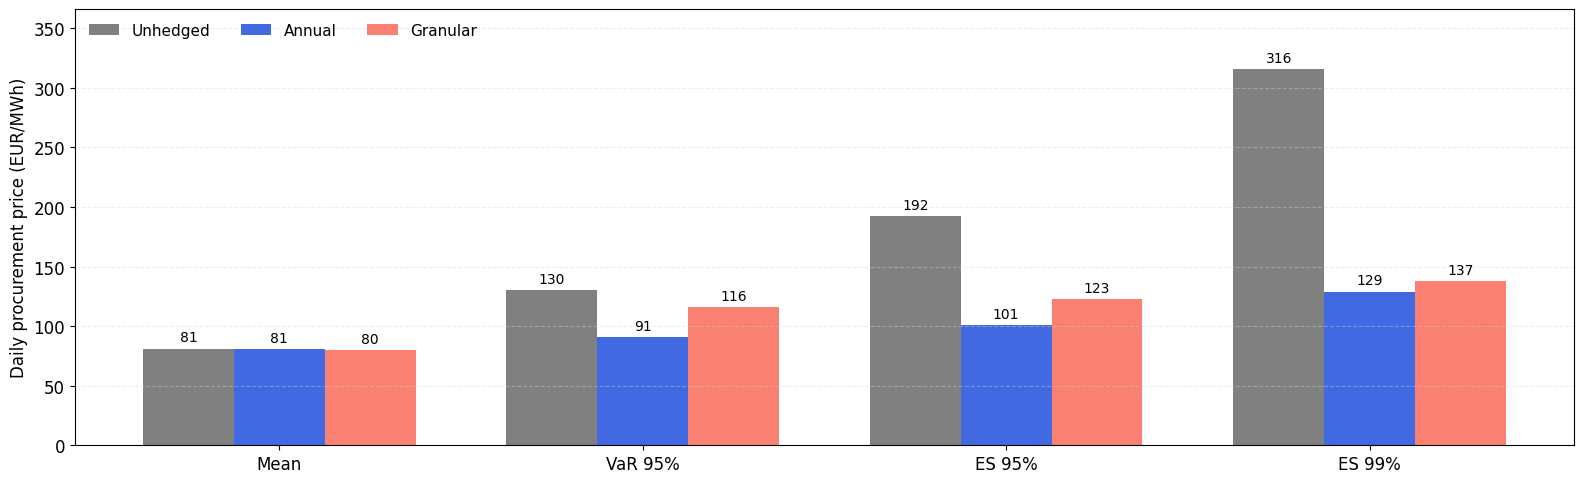

In [35]:
tail_columns = ["Mean Daily Price EUR/MWh", "VaR95 EUR/MWh", "ES95 EUR/MWh", "ES99 EUR/MWh"]
tail_positions = np.arange(len(tail_columns))
bar_width = 0.25
plt.figure(figsize=(16, 5))
for i, strategy in enumerate(strategies):
    bars = plt.bar(tail_positions + (i - 1) * bar_width, daily_price_tail.loc[strategy, tail_columns].to_numpy(dtype=float), width=bar_width, color=strategy_colors[strategy], label=strategy_names[strategy])
    plt.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)
plt.xticks(tail_positions, ["Mean", "VaR 95%", "ES 95%", "ES 99%"])
plt.ylabel("Daily procurement price (EUR/MWh)")
plt.ylim(0, daily_price_tail[tail_columns].to_numpy().max() * 1.16)
plt.legend(frameon=False, ncol=3, loc="upper left")
plt.grid(axis="y", linestyle="--", color="lightgray", alpha=0.4)
plt.tight_layout()
for extension in ["pdf", "png"]:
    plt.savefig(figure_dir / f"Daily Procurement Price Tail Risk.{extension}", dpi=300, transparent=True)
plt.show()

In [30]:
episode = costs[costs["timestamp_local"].ge(episode_start) & costs["timestamp_local"].lt(episode_end)].copy()
episode_rows = []
for strategy in strategies:
    episode_rows.append({"Strategy": strategy, "Futures EUR": episode[futures_columns[strategy]].sum(), "Day-Ahead Residual EUR": episode[residual_cost_columns[strategy]].sum(), "Imbalance EUR": episode["imbalance_settlement_eur"].sum(), "Total EUR": episode[cost_columns[strategy]].sum()})
december_episode = pd.DataFrame(episode_rows).set_index("Strategy")
december_episode.to_csv(table_dir / "04_december_episode.csv")
episode_table = december_episode.rename(index=strategy_names, columns={"Futures EUR": "Futures", "Day-Ahead Residual EUR": "DA residual", "Imbalance EUR": "Imbalance", "Total EUR": "Total"}).rename_axis(None)
(table_dir / "04_december_episode.tex").write_text(r"{\small" + "\n" + episode_table.to_latex(float_format=lambda value: f"{value:,.0f}", escape=True, column_format="lrrrr") + "}\n", encoding="utf-8")
event_prices = episode.groupby(episode["timestamp_local"].dt.strftime("%Y-%m-%d"))["day_ahead_price_eur_mwh"].agg(["mean", "max"])
event_prices.columns = ["Mean DA Price EUR/MWh", "Maximum DA Price EUR/MWh"]
event_prices.index.name = "Date"
event_prices.to_csv(table_dir / "04_december_price_summary.csv")
peak_row = episode.loc[episode["day_ahead_price_eur_mwh"].idxmax()]
display(december_episode.round(2), event_prices.round(2))
print(f"Peak DA price: {peak_row['day_ahead_price_eur_mwh']:.2f} EUR/MWh at {peak_row['timestamp_local']:%Y-%m-%d %H:%M %Z}")

,Futures EUR,Day-Ahead Residual EUR,Imbalance EUR,Total EUR
Strategy,,,,
UNHEDGED,0.00,101502.76,8034.67,109537.43
COARSE_CAL,20204.19,9360.15,8034.67,37599.01
GRANULAR,29547.30,2190.79,8034.67,39772.75


,Mean DA Price EUR/MWh,Maximum DA Price EUR/MWh
Date,,
2024-12-11,266.54,445.08
2024-12-12,395.34,936.28


Peak DA price: 936.28 EUR/MWh at 2024-12-12 17:00 CET


In [31]:
annual_error = np.max(np.abs(annual_cost_risk["Final Cost EUR"] - stage5.loc[strategies, "Final Cost EUR"]))
daily_error = np.max(np.abs(daily[list(cost_columns.values())].sum().to_numpy() - annual_cost_risk["Final Cost EUR"].to_numpy()))
monthly_error = np.max(np.abs(monthly[list(cost_columns.values())].sum().to_numpy() - annual_cost_risk["Final Cost EUR"].to_numpy()))
episode_error = np.max(np.abs(december_episode[["Futures EUR", "Day-Ahead Residual EUR", "Imbalance EUR"]].sum(axis=1) - december_episode["Total EUR"]))
checks = pd.DataFrame([("Complete quarter-hour rows", len(costs), 35136, len(costs) == 35136), ("Local calendar days", len(daily), 366, len(daily) == 366), ("Local calendar months", len(monthly), 12, len(monthly) == 12), ("Annual vs Stage 5 error EUR", annual_error, 0, annual_error < 1e-6), ("Daily aggregation error EUR", daily_error, 0, daily_error < 1e-6), ("Monthly aggregation error EUR", monthly_error, 0, monthly_error < 1e-6), ("December episode rows", len(episode), 192, len(episode) == 192), ("December cost identity error EUR", episode_error, 0, episode_error < 1e-6)], columns=["Check", "Observed", "Expected", "Passed"])
checks.to_csv(table_dir / "04_cost_risk_checks.csv", index=False)
assert checks["Passed"].all(), "Cost and risk reconciliation failed."
display(checks)

,Check,Observed,Expected,Passed
0,Complete quarter-hour rows,3.513600e+04,35136,True
1,Local calendar days,3.660000e+02,366,True
2,Local calendar months,1.200000e+01,12,True
3,Annual vs Stage 5 error EUR,9.313226e-10,0,True
4,Daily aggregation error EUR,4.656613e-10,0,True
5,Monthly aggregation error EUR,4.656613e-10,0,True
6,December episode rows,1.920000e+02,192,True
7,December cost identity error EUR,1.455192e-11,0,True


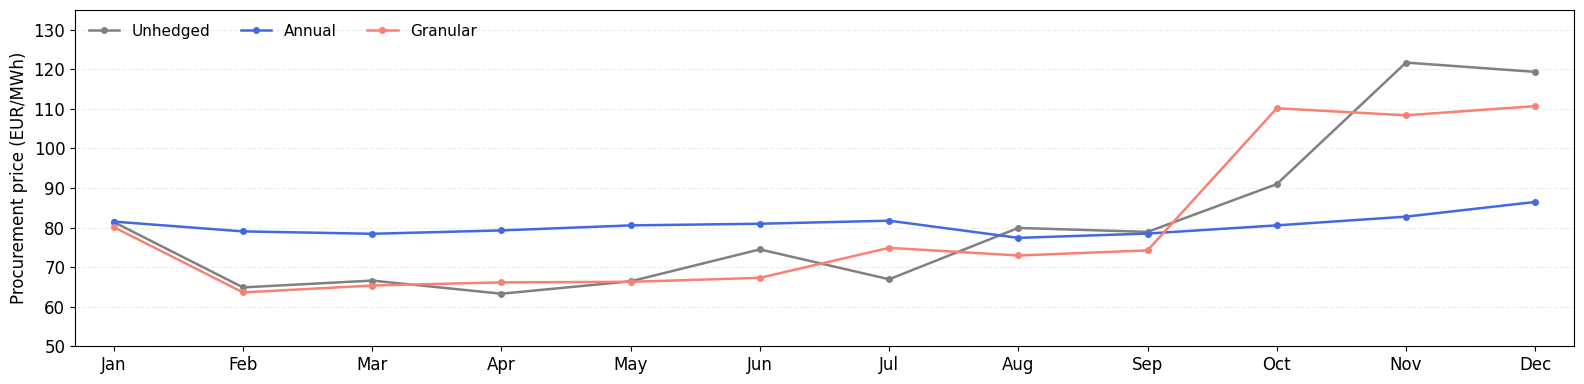

In [32]:
plt.figure(figsize=(16, 4))
for strategy in strategies:
    plt.plot(np.arange(1, 13), monthly[f"price_{strategy.lower()}_eur_mwh"], color=strategy_colors[strategy], marker="o", markersize=4, linewidth=1.8, label=strategy_names[strategy])
plt.xticks(np.arange(1, 13), pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%b"))
plt.xlim(0.7, 12.3)
plt.ylim(50, 135)
plt.ylabel("Procurement price (EUR/MWh)")
plt.legend(frameon=False, ncol=3, loc="upper left")
plt.grid(axis="y", linestyle="--", color="lightgray", alpha=0.4)
plt.tight_layout()
for extension in ["pdf", "png"]:
    plt.savefig(figure_dir / f"Monthly Procurement Price.{extension}", dpi=300, transparent=True)
plt.show()

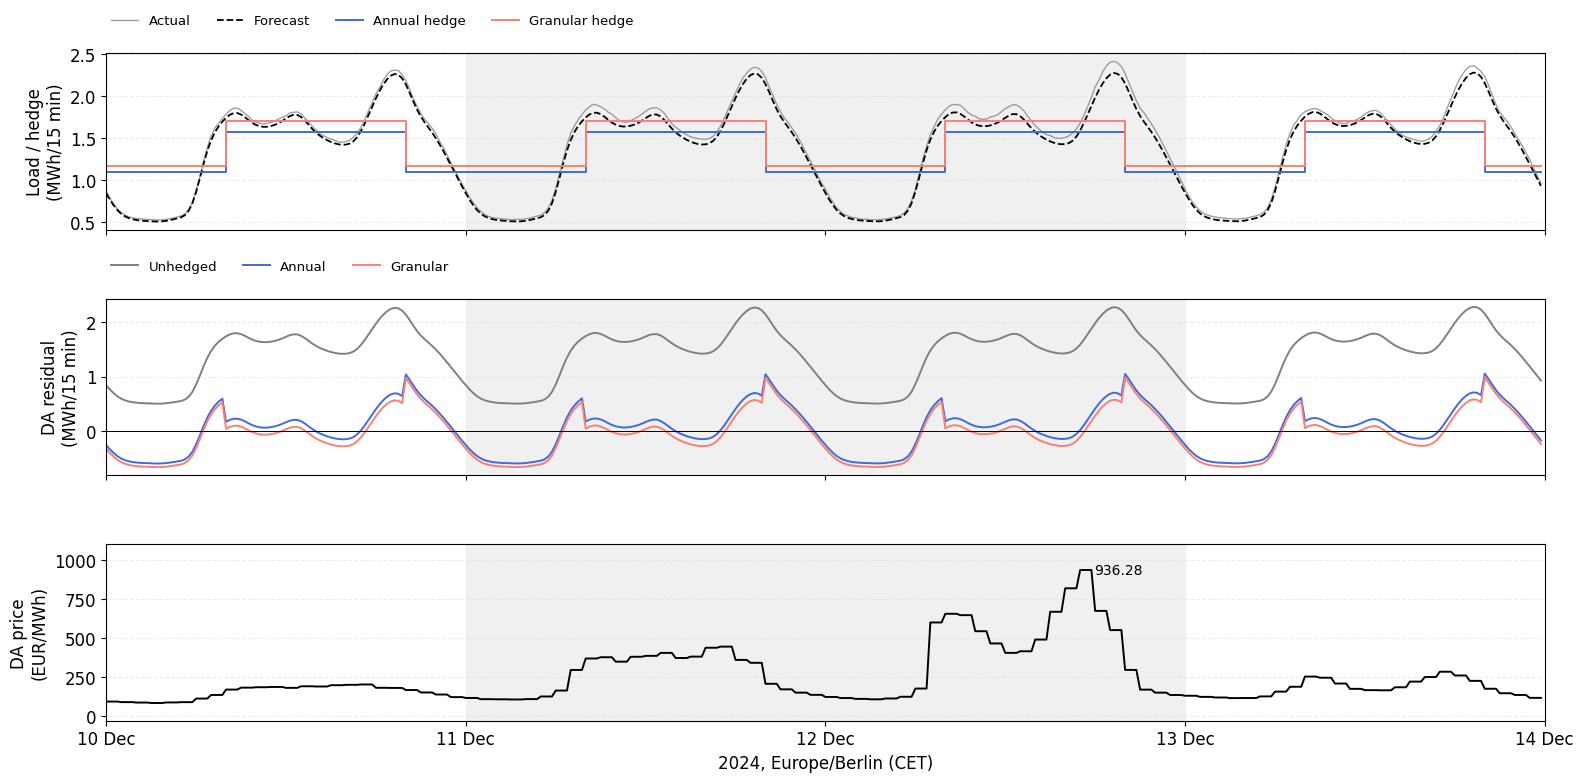

In [33]:
window = costs[costs["timestamp_local"].ge(plot_start) & costs["timestamp_local"].lt(plot_end)].copy()
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
axes[0].plot(window["timestamp_local"], window["total_actual_mwh"], color="gray", linewidth=1, alpha=0.75, label="Actual")
axes[0].plot(window["timestamp_local"], window["forecast_mwh"], color="black", linestyle="--", linewidth=1.3, label="Forecast")
for strategy, hedge_column in [("COARSE_CAL", "hedge_coarse_mwh"), ("GRANULAR", "hedge_granular_mwh")]:
    axes[0].step(window["timestamp_local"], window[hedge_column], where="post", color=strategy_colors[strategy], linewidth=1.4, label=f"{strategy_names[strategy]} hedge")
axes[0].set_ylabel("Load / hedge\n(MWh/15 min)")
axes[0].legend(frameon=False, ncol=4, fontsize=9.5, loc="upper left", bbox_to_anchor=(0, 1.25), borderaxespad=0)
for strategy in strategies:
    axes[1].plot(window["timestamp_local"], window[residual_columns[strategy]], color=strategy_colors[strategy], linewidth=1.4, label=strategy_names[strategy])
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set_ylabel("DA residual\n(MWh/15 min)")
axes[1].legend(frameon=False, ncol=3, fontsize=9.5, loc="upper left", bbox_to_anchor=(0, 1.25), borderaxespad=0)
axes[2].plot(window["timestamp_local"], window["day_ahead_price_eur_mwh"], color="black", linewidth=1.4)
axes[2].set_ylabel("DA price\n(EUR/MWh)")
axes[2].set_ylim(-30, 1100)
axes[2].annotate(f"{peak_row['day_ahead_price_eur_mwh']:.2f}", xy=(peak_row["timestamp_local"], peak_row["day_ahead_price_eur_mwh"]), xytext=(10, 0), textcoords="offset points", fontsize=10, va="center")
axes[2].xaxis.set_major_locator(mdates.DayLocator(tz=timezone))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d %b", tz=timezone))
axes[2].set_xlabel("2024, Europe/Berlin (CET)")
for axis in axes:
    axis.axvspan(episode_start, episode_end, color="0.94", zorder=0)
    axis.set_xlim(plot_start, plot_end)
    axis.grid(axis="y", linestyle="--", color="lightgray", alpha=0.4)
fig.tight_layout(h_pad=1.15)
for extension in ["pdf", "png"]:
    fig.savefig(figure_dir / f"December Residual Exposure.{extension}", dpi=300, transparent=True)
plt.show()

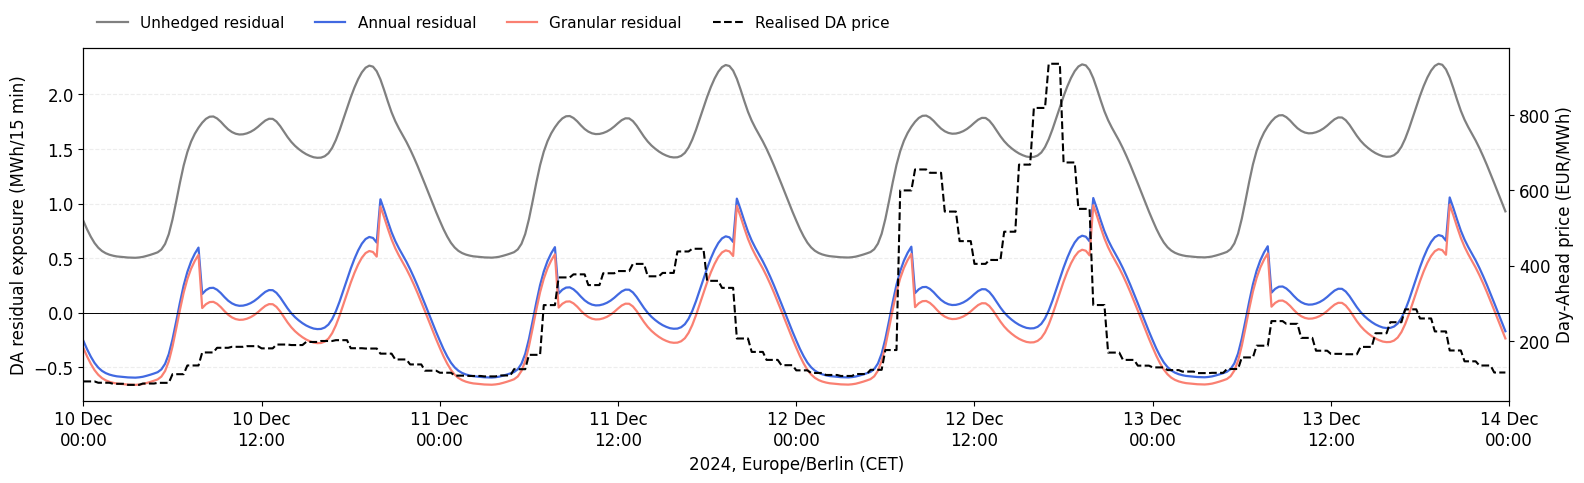

In [34]:
window = costs[costs["timestamp_local"].ge(plot_start) & costs["timestamp_local"].lt(plot_end)].copy()
fig, residual_axis = plt.subplots(figsize=(16, 5))
for strategy in strategies:
    residual_axis.plot(window["timestamp_local"], window[residual_columns[strategy]], color=strategy_colors[strategy], linewidth=1.6, label=f"{strategy_names[strategy]} residual")
residual_axis.axhline(0, color="black", linewidth=0.7)
residual_axis.set_ylabel("DA residual exposure (MWh/15 min)")
price_axis = residual_axis.twinx()
price_axis.plot(window["timestamp_local"], window["day_ahead_price_eur_mwh"], color="black", linestyle="--", linewidth=1.5, label="Realised DA price")
price_axis.set_ylabel("Day-Ahead price (EUR/MWh)")
residual_axis.set_xlim(plot_start, plot_end)
residual_axis.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12], tz=timezone))
residual_axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=timezone))
residual_axis.set_xlabel("2024, Europe/Berlin (CET)")
residual_axis.grid(axis="y", linestyle="--", color="lightgray", alpha=0.4)
residual_lines, residual_labels = residual_axis.get_legend_handles_labels()
price_lines, price_labels = price_axis.get_legend_handles_labels()
residual_axis.legend(residual_lines + price_lines, residual_labels + price_labels, frameon=False, ncol=4, loc="lower left", bbox_to_anchor=(0, 1.01))
fig.tight_layout()
for extension in ["pdf", "png"]:
    fig.savefig(figure_dir / f"December Residual Exposure and DA Price.{extension}", dpi=300, transparent=True)
plt.show()